# Linear and Polynomial Regression

I start with a line, move to several features, and then check what changes when I add constraints or polynomial terms.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes, make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


## 1. One-feature regression

This example makes the slope and intercept easy to see. I draw the fitted line on a sorted grid so the plot does not zigzag.


Coefficient: 23.016
Intercept: 2.943
Training R^2: 0.614
Test R^2: 0.677


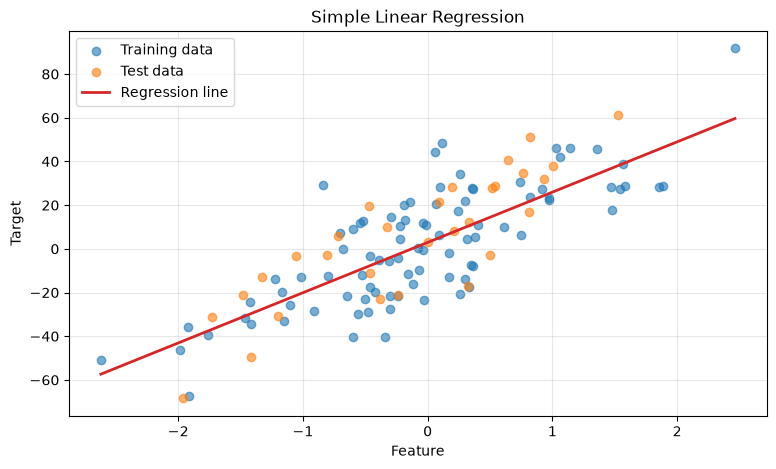

In [2]:
X_simple, y_simple = make_regression(
    n_samples=120, n_features=1, noise=18, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y_simple, test_size=0.25, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
test_predictions = linear_model.predict(X_test)

print(f"Coefficient: {linear_model.coef_[0]:.3f}")
print(f"Intercept: {linear_model.intercept_:.3f}")
print(f"Training R^2: {linear_model.score(X_train, y_train):.3f}")
print(f"Test R^2: {r2_score(y_test, test_predictions):.3f}")

# Predict on a sorted grid so the fitted line is drawn correctly.
x_grid = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
plt.figure(figsize=(9, 5))
plt.scatter(X_train[:, 0], y_train, alpha=0.6, label="Training data")
plt.scatter(X_test[:, 0], y_test, alpha=0.6, label="Test data")
plt.plot(x_grid[:, 0], linear_model.predict(x_grid), color="tab:red", linewidth=2, label="Regression line")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Simple Linear Regression")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 2. Diabetes regression

I use the supported diabetes dataset instead of the removed Boston housing dataset. The score is moderate, which is reasonable for a simple linear baseline.


In [3]:
diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.2, random_state=42
)

# The pipeline keeps preprocessing tied to the estimator.
diabetes_model = make_pipeline(StandardScaler(), LinearRegression())
diabetes_model.fit(X_train, y_train)
diabetes_predictions = diabetes_model.predict(X_test)

print(f"Test MSE: {mean_squared_error(y_test, diabetes_predictions):.2f}")
print(f"Test R^2: {r2_score(y_test, diabetes_predictions):.3f}")


Test MSE: 2900.19
Test R^2: 0.453


## 3. Positive coefficients

`positive=True` prevents negative coefficients. This constraint only makes sense when negative effects would be unreasonable for the problem.


In [4]:
# Compare the constraint using the same split and metric.
models = {
    "Ordinary least squares": LinearRegression(),
    "Non-negative least squares": LinearRegression(positive=True),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(f"{name} test R^2: {r2_score(y_test, predictions):.3f}")


Ordinary least squares test R^2: 0.453
Non-negative least squares test R^2: 0.453


## 4. Polynomial regression

Here I use BMI alone and add curved terms. Its score should not be compared directly with the earlier model that uses every feature.


Degree-3 test R^2: 0.233


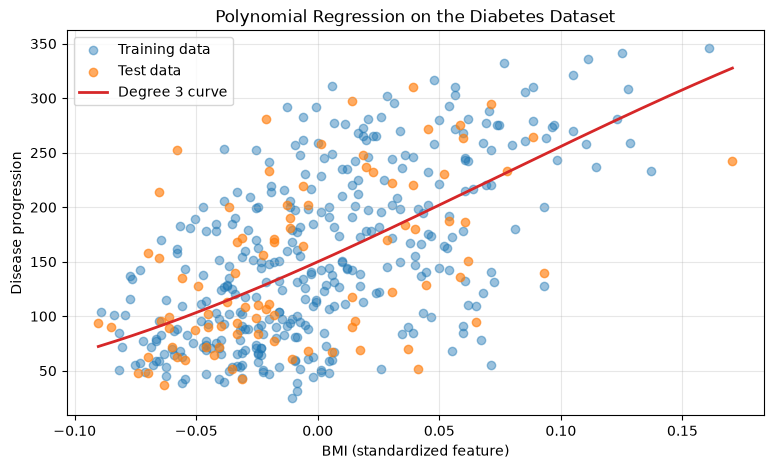

In [5]:
X_bmi = diabetes.data[:, [2]]
y = diabetes.target
X_train, X_test, y_train, y_test = train_test_split(
    X_bmi, y, test_size=0.2, random_state=42
)

# Degree 3 adds curvature without making this small example too complex.
degree = 3
polynomial_model = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    StandardScaler(),
    LinearRegression(),
)
polynomial_model.fit(X_train, y_train)
polynomial_predictions = polynomial_model.predict(X_test)
print(f"Degree-{degree} test R^2: {r2_score(y_test, polynomial_predictions):.3f}")

# Predict on a sorted grid so the fitted line is drawn correctly.
x_grid = np.linspace(X_bmi.min(), X_bmi.max(), 300).reshape(-1, 1)
plt.figure(figsize=(9, 5))
plt.scatter(X_train[:, 0], y_train, alpha=0.45, label="Training data")
plt.scatter(X_test[:, 0], y_test, alpha=0.65, label="Test data")
plt.plot(x_grid[:, 0], polynomial_model.predict(x_grid), color="tab:red", linewidth=2, label=f"Degree {degree} curve")
plt.xlabel("BMI (standardized feature)")
plt.ylabel("Disease progression")
plt.title("Polynomial Regression on the Diabetes Dataset")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## What I learned

More flexibility does not guarantee a better test score. The degree-3 BMI model performs worse here, so validation matters more than how well a curve looks.
